In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from pathlib import Path
from facenet_pytorch import MTCNN, InceptionResnetV1
import yaml
import json

In [24]:
torch.__version__
%uv pip uninstall yml

Note: you may need to restart the kernel to use updated packages.


Using Python 3.12.10 environment at: E:\cours ifri\Programmation et BD\Python\Projet IA\Face Detection\.env
Uninstalled 1 package in 13ms
 - yml==0.0.1


Le **MTCNN** (Multi-task Cascaded Convolutional Networks) est l'étape indispensable qui se situe avant la reconnaissance d'identité. Son rôle est de détecter les visages et de les préparer pour le modèle de Deep Learning.

**InceptionResnetV1** qui est un modèle hybride qui combine Inception de Google pour la récupération des détails fins et les formes globales et ResNet pour entrainer des reseaux profonds sans perdre l'information du début.  
Le modele préentrainé ici est le modele **VGGFace2** contient plus de 3,3 millions d'images de 9 000 individus différents. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.91015625].


Taille image originale (459, 668, 3)


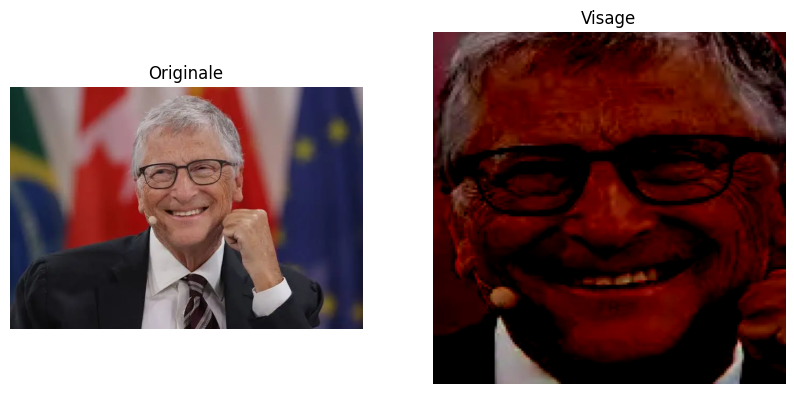

Dimension avant torch.Size([3, 160, 160])
Dimension apres torch.Size([1, 3, 160, 160])
Embedding shape: torch.Size([1, 512])


In [14]:


# Détection de visage
mtcnn = MTCNN(image_size=160 , margin=20)

# Modèle FaceNet pré-entraîné
model = InceptionResnetV1(pretrained='vggface2').eval()

# Charger image de test

image = '../data/bill.jpg'

try:

    img = cv2.imread(str(image))
    print(f"Taille image originale {img.shape}")
    
    
    if img is None:
        raise ValueError(f"Impossible de lire l'image: {image}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Détecter et crop visage
    face = mtcnn(img)

    if face is not None:
        
        # Créer une figure avec 1 ligne et 2 colonnes
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Image originale
        axes[0].imshow(img)
        axes[0].set_title('Originale')
        axes[0].axis('off') 

        # Visage détecté
        axes[1].imshow(face.permute(1,2,0).detach().cpu().numpy())
        axes[1].set_title('Visage')
        axes[1].axis('off')
            
        
        plt.show()
        
        # Ajouter batch dimension
        
        print(f"Dimension avant {face.shape}")
        
        face = face.unsqueeze(0)
        
        print(f"Dimension apres {face.shape}")
        
        # Extraire embedding
        embedding = model(face)

        print("Embedding shape:", embedding.shape)
    else:
        print(f"Aucun visage détecté dans {image}")
        
except Exception as e:
    print("Une erreur s'est produite" , e)

In [ ]:
def img_to_embedding(face) -> np.ndarray:
    """
    Transforme le visage détecté en vecteur d'embedding.
    
    """
    if face is None:
        raise ValueError("Aucun visage détecté pour calculer l'embedding.")

    face_tensor = face if face.ndim == 4 else face.unsqueeze(0)

    with torch.no_grad():
        embedding = model(face_tensor).detach().cpu().numpy().astype("float32")

    return embedding

In [19]:
import faiss
import numpy as np

# 1. Préparation des données (vecteurs à indexer)
d = 64                           # dimension
nb = 100000                      # nombre de vecteurs
nq = 10                          # nombre de requêtes
np.random.seed(1234)             
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# 2. Création de l'index
index = faiss.IndexFlatL2(d)   # utilise L2 (euclidien)
print(index.is_trained)
index.add(xb)                  # ajout des vecteurs
print(index.ntotal)

# 3. Recherche
k = 4                          # nombre de voisins à retourner
D, I = index.search(xq, k)     # D=distances, I=index
print(D)                   # indices des 5 premières requêtes


True
100000
[[5.6056523 5.8574157 5.864208  5.919097 ]
 [4.840672  5.120595  5.237412  5.274076 ]
 [5.315844  5.8178043 5.8179564 5.9018445]
 [5.2199526 5.233007  5.3548164 5.5242834]
 [4.865439  5.146442  5.22618   5.3562737]
 [5.024254  5.2272964 5.3044915 5.3150125]
 [4.998722  5.170163  5.1894617 5.2167225]
 [5.341447  5.4327292 5.60601   5.6427364]
 [5.2383704 5.385066  5.600378  5.6291046]
 [5.7070546 5.7532673 5.8351126 5.9764414]]


In [16]:

# Convertir le tenseur en array numpy
embeddings_array = embedding.detach().cpu().numpy()
np.save('../data/embeddings.npy', embeddings_array)

In [ ]:
# Il faut charger les anciens d'abord ; faire un concat ; et ensuite enregistrer de nouveau
a = np.load('../data/embeddings.npy').shape
a.e

(1, 512)

In [31]:
a = np.array([1 , 2 , 3])
a = a.reshape(1 , -1)
a.shape

(1, 3)

In [27]:
import yaml

# Ouvrir le fichier YAML en mode lecture
with open("../configs/config.yaml", "r") as file:
    # Charger le contenu du fichier en tant que dictionnaire Python
    config = yaml.safe_load(file)

# Afficher le contenu du fichier chargé
print(config)

{'face_recognition': {'model_name': 'face_recognition_facenet', 'params': {'distance_threshold': 0.75, 'model_path': '../../../data/models/face_recognition_facenet/squeezenet_VGGFace2/model-20180204-160909.ckpt-266000', 'use_cuda': True}}}
